# 🛒 Customer Analytics & Order Intelligence - Python Exploratory Data Analysis (EDA)

## 📌 Project Overview

This notebook performs Exploratory Data Analysis (EDA) on the Brazilian E-Commerce Public Dataset (Olist) using Python. The objective is to analyze customer purchasing behavior, revenue trends, product performance, seller performance, payment methods, and customer segmentation (RFM Analysis) to generate actionable business insights.

The analysis follows a structured workflow beginning with data loading, data quality assessment, data cleaning, table merging, feature engineering, exploratory analysis, and visualization. The insights generated in this notebook complement the SQL analysis and support the development of an AI-assisted interactive dashboard.

---

## 🎯 Objectives

- Understand the structure and quality of the e-commerce dataset.
- Perform data cleaning and validation.
- Merge multiple relational tables into a unified analytical dataset.
- Analyze customer purchasing behavior and revenue performance.
- Evaluate product, seller, and payment performance.
- Perform RFM (Recency, Frequency, Monetary) Analysis for customer segmentation.
- Create professional visualizations to support business decision-making.

---

## 🛠️ Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib

---

## 📂 Dataset

**Dataset:** Brazilian E-Commerce Public Dataset (Olist)

**Tables Used:**

- Customers
- Orders
- Order Items
- Products
- Payments
- Sellers

**Records:**

- ~100,000 Orders
- ~99,000 Customers
- ~112,000 Order Items
- ~33,000 Products
- ~103,000 Payment Records
- ~3,000 Sellers

---

## 🔄 Analysis Workflow

1. Import Libraries
2. Load Datasets
3. Data Exploration
4. Data Quality Assessment
5. Data Cleaning
6. Merge Tables
7. Feature Engineering
8. Exploratory Data Analysis (EDA)
9. Customer Analytics
10. Business Visualizations
11. Business Insights
12. Interview Story (STAR)
13. Conclusion
---

**Author:** Sameer Sharma

# 📚 Step 1: Import Libraries

The first step is to import the Python libraries required for data manipulation, numerical analysis, and data visualization.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 📂 Step 2: Load the Datasets

Load all six datasets that together form the Brazilian E-Commerce relational database.

In [17]:
customers = pd.read_csv("olist_customers_dataset.csv")
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")

# 🔍 Step 3: Data Exploration

Inspect the structure, dimensions, and first few records of each dataset before performing data cleaning and merging.

In [18]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Order Items": order_items,
    "Products": products,
    "Payments": payments,
    "Sellers": sellers
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print(df.head())


Customers
Shape: (99441, 5)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Orders
Shape: (99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49

# 📋 Step 4: Dataset Information

Review the data types and identify potential missing values before data cleaning.

In [19]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.info())


Customers
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB
None

Orders
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approv

# 📊 Step 5: Statistical Summary

Generate descriptive statistics to understand the numerical distribution of each dataset.

In [20]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.describe(include="all"))


Customers
                             customer_id                customer_unique_id  \
count                              99441                             99441   
unique                             99441                             96096   
top     06b8999e2fba1a1fbc88172c00ba8bc7  8d50f5eadf50201ccdcedfb9e2ac8455   
freq                                   1                                17   
mean                                 NaN                               NaN   
std                                  NaN                               NaN   
min                                  NaN                               NaN   
25%                                  NaN                               NaN   
50%                                  NaN                               NaN   
75%                                  NaN                               NaN   
max                                  NaN                               NaN   

        customer_zip_code_prefix customer_city custo

# 🧹 Step 6: Missing Value Analysis

Check each dataset for missing values to identify columns that may require cleaning or imputation before analysis.

In [21]:
for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm  

# 🧹 Step 7: Duplicate Record Check

Check each dataset for duplicate records to ensure data integrity before analysis.

In [22]:
for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicate rows")

Customers: 0 duplicate rows
Orders: 0 duplicate rows
Order Items: 0 duplicate rows
Products: 0 duplicate rows
Payments: 0 duplicate rows
Sellers: 0 duplicate rows


# 📊 Step 8: Missing Value Percentage

Calculate the percentage of missing values in each dataset to evaluate data completeness.

In [23]:
for name, df in datasets.items():
    print(f"\n{name}")

    missing = (df.isnull().sum() / len(df)) * 100

    print(missing[missing > 0].sort_values(ascending=False))


Customers
Series([], dtype: float64)

Orders
order_delivered_customer_date    2.981668
order_delivered_carrier_date     1.793023
order_approved_at                0.160899
dtype: float64

Order Items
Series([], dtype: float64)

Products
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

Payments
Series([], dtype: float64)

Sellers
Series([], dtype: float64)


# 🧹 Step 9: Remove Duplicate Records

Remove duplicate records from each dataset if any duplicates are found.

In [24]:
customers.drop_duplicates(inplace=True)
orders.drop_duplicates(inplace=True)
order_items.drop_duplicates(inplace=True)
products.drop_duplicates(inplace=True)
payments.drop_duplicates(inplace=True)
sellers.drop_duplicates(inplace=True)

# ✅ Step 10: Verify Dataset Shapes

Confirm the final dimensions of each dataset after data cleaning.

In [25]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Customers: (99441, 5)
Orders: (99441, 8)
Order Items: (112650, 7)
Products: (32951, 9)
Payments: (103886, 5)
Sellers: (3095, 4)


# 🔗  Merge Tables

The Olist dataset consists of multiple relational tables. In this step, the datasets are merged into a single master DataFrame using common keys.

This unified dataset will be used for feature engineering, exploratory data analysis (EDA), customer segmentation, and business visualizations.

In [26]:
master_df = customers.merge(orders,
                          on="customer_id"
                          ,how="inner")

master_df.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [27]:
master_df = master_df.merge(
    order_items,
    on="order_id",
    how="inner"
)

master_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


In [28]:
master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

master_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0


In [29]:
master_df = master_df.merge(
    payments,
    on="order_id",
    how="left"
)

master_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,1.0,credit_card,2.0,146.87
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,1.0,credit_card,8.0,335.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,1.0,credit_card,7.0,157.73
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,1.0,credit_card,1.0,173.30
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,1.0,credit_card,8.0,252.25


In [30]:
master_df = master_df.merge(
    sellers,
    on="seller_id",
    how="left"
)

master_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,54.0,64.0,31.0,1.0,credit_card,2.0,146.87,8577,itaquaquecetuba,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,89.0,15.0,40.0,1.0,credit_card,8.0,335.48,88303,itajai,SC
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,52.0,52.0,17.0,1.0,credit_card,7.0,157.73,8577,itaquaquecetuba,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,56.0,51.0,28.0,1.0,credit_card,1.0,173.30,8577,itaquaquecetuba,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,45.0,15.0,35.0,1.0,credit_card,8.0,252.25,14940,ibitinga,SP


# 📊 Verify the Master Dataset

Check the dimensions and preview the merged dataset before proceeding with feature engineering.

In [31]:
print(master_df.shape)

master_df.head()

master_df.columns

master_df.info()

(117604, 33)
<class 'pandas.DataFrame'>
RangeIndex: 117604 entries, 0 to 117603
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    117604 non-null  str    
 1   customer_unique_id             117604 non-null  str    
 2   customer_zip_code_prefix       117604 non-null  int64  
 3   customer_city                  117604 non-null  str    
 4   customer_state                 117604 non-null  str    
 5   order_id                       117604 non-null  str    
 6   order_status                   117604 non-null  str    
 7   order_purchase_timestamp       117604 non-null  str    
 8   order_approved_at              117589 non-null  str    
 9   order_delivered_carrier_date   116359 non-null  str    
 10  order_delivered_customer_date  115037 non-null  str    
 11  order_estimated_delivery_date  117604 non-null  str    
 12  order_item_id               

# ⚙️ Feature Engineering

Create additional features from the existing data to simplify analysis and generate meaningful business insights.

The newly created features include purchase year, month, day, month name, day name, and total order value.

In [32]:
master_df["order_purchase_timestamp"] = pd.to_datetime(
    master_df["order_purchase_timestamp"]
)

In [33]:
master_df["Purchase_Year"] = master_df["order_purchase_timestamp"].dt.year

In [34]:
master_df["Purchase_Month"] = master_df["order_purchase_timestamp"].dt.month

In [35]:
master_df["Month_Name"] = master_df["order_purchase_timestamp"].dt.month_name()

In [36]:
master_df["Purchase_Day"] = master_df["order_purchase_timestamp"].dt.day

In [37]:
master_df["Day_Name"] = master_df["order_purchase_timestamp"].dt.day_name()

In [38]:
master_df["Quarter"] = master_df["order_purchase_timestamp"].dt.quarter

In [39]:
master_df["Total_Order_Value"] = (
    master_df["price"] +
    master_df["freight_value"]
)

# 📊 Verify Engineered Features

Preview the newly created columns before proceeding with exploratory data analysis.

In [40]:
master_df[
[
"Purchase_Year",
"Purchase_Month",
"Month_Name",
"Purchase_Day",
"Day_Name",
"Quarter",
"Total_Order_Value"
]
].head()

,Purchase_Year,Purchase_Month,Month_Name,Purchase_Day,Day_Name,Quarter,Total_Order_Value
0,2017,5,May,16,Tuesday,2,146.87
1,2018,1,January,12,Friday,1,335.48
2,2018,5,May,19,Saturday,2,157.73
3,2018,3,March,13,Tuesday,1,173.30
4,2018,7,July,29,Sunday,3,252.25


# 📊 Exploratory Data Analysis (EDA)

Explore customer purchasing behavior, revenue trends, product performance, seller performance, and payment preferences using business-oriented visualizations.

The objective is to identify meaningful patterns that support data-driven business decisions.

## 📈 Monthly Revenue Trend

Analyze monthly revenue to identify seasonal sales patterns and business growth over time.

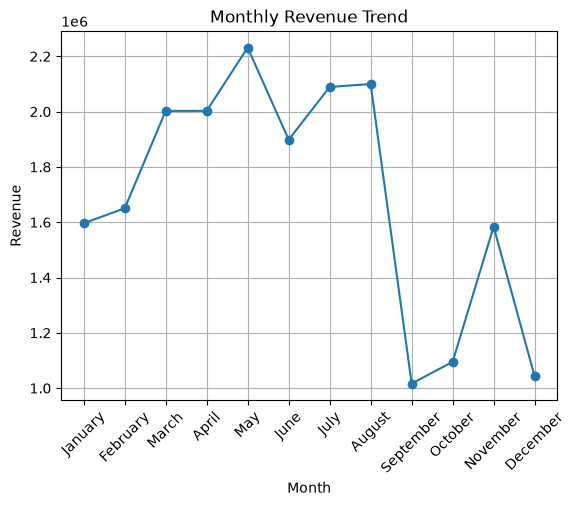

In [41]:
monthly_revenue = master_df.groupby("Month_Name")["payment_value"].sum()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = monthly_revenue.reindex(month_order)

plt.plot(monthly_revenue.index, monthly_revenue.values,marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 📊 Revenue by Product Category

Identify the product categories contributing the highest revenue.

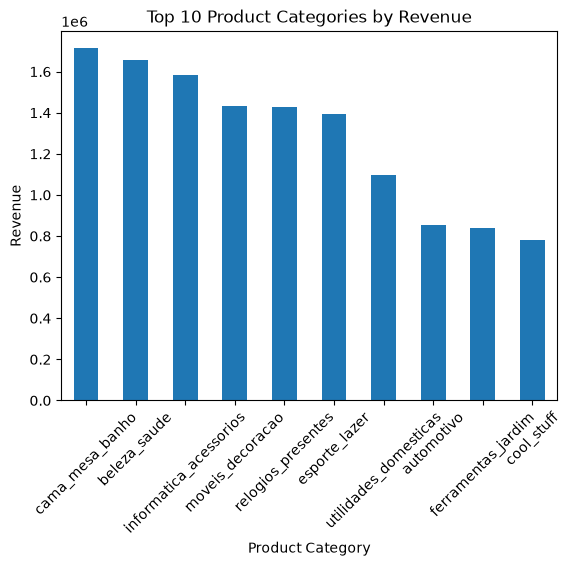

In [42]:
top_categories = (
    master_df.groupby("product_category_name")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_categories.plot(kind="bar")
plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 📍 Revenue by Customer State

Analyze revenue contribution across customer states.

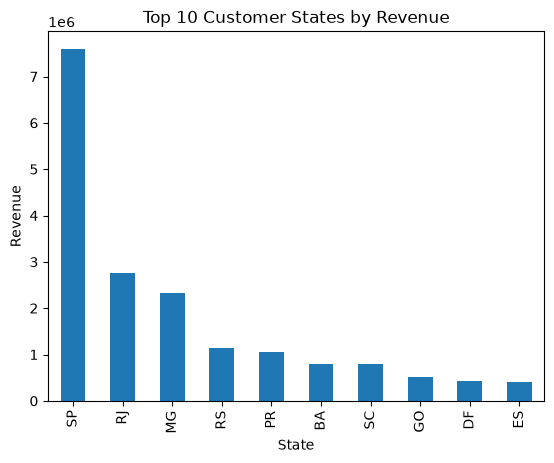

In [43]:
state_revenue = (
    master_df.groupby("customer_state")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_revenue.plot(kind="bar")
plt.title("Top 10 Customer States by Revenue")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

## 💳 Payment Method Distribution

Analyze customer payment preferences across different payment methods.

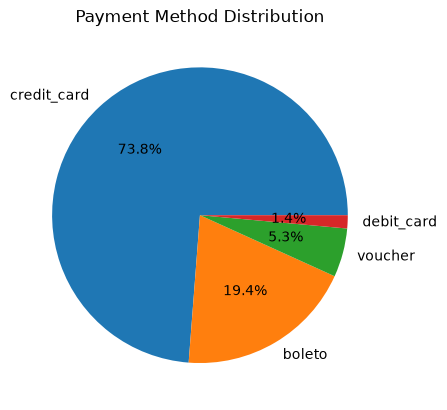

In [44]:
payment_method = master_df["payment_type"].value_counts()


plt.pie(payment_method,
        labels=payment_method.index,
      autopct="%1.1f%%")

plt.title("Payment Method Distribution")
plt.show()

## 🏪 Top Sellers by Revenue

Identify the sellers generating the highest revenue.

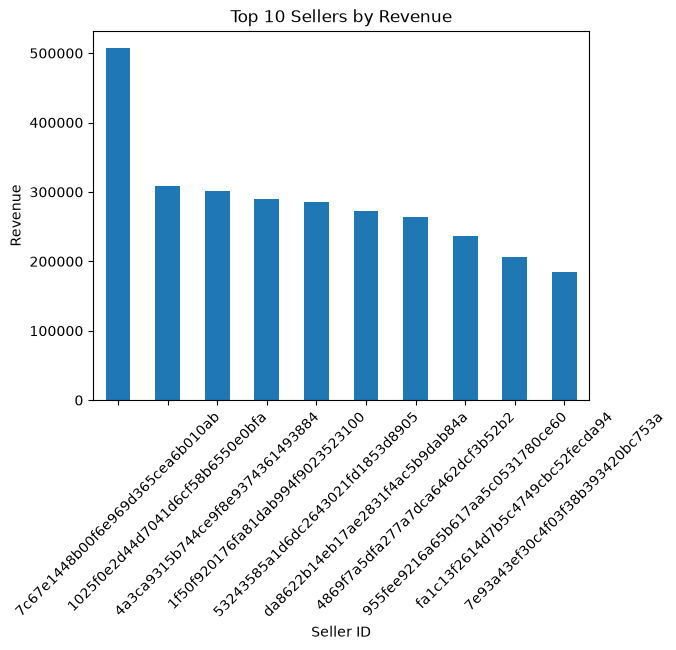

In [45]:
seller_revenue = (
    master_df.groupby("seller_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

seller_revenue.plot(kind="bar")
plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Seller ID")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

## 💰 Top 10 Customers by Revenue

Identify customers contributing the highest revenue to the business.

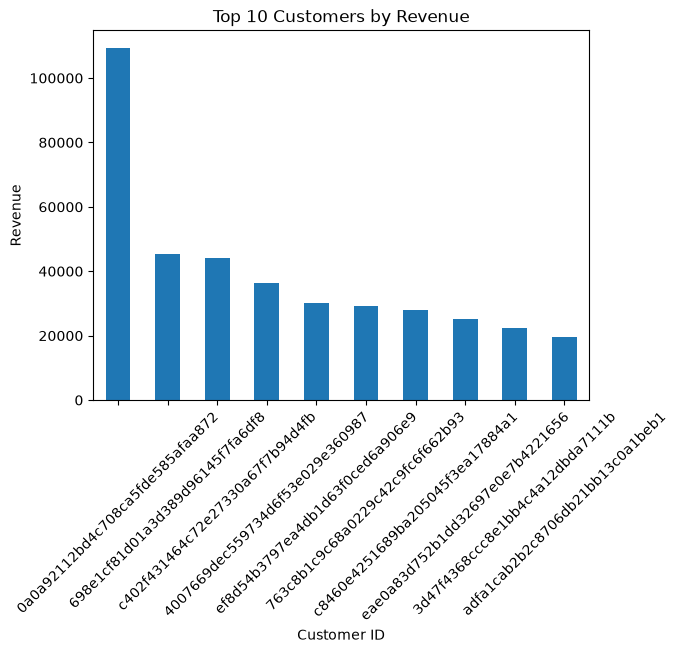

In [46]:
top_customers = (
    master_df.groupby("customer_unique_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## 🛍️ Customer Purchase Frequency

Analyze how frequently customers place orders to identify repeat customers.

In [47]:
purchase_frequency = (
    master_df.groupby("customer_unique_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)

purchase_frequency

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    16
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
47c1a3033b8b77b3ab6e109eb4d5fdf3     6
12f5d6e1cbf93dafd9dcc19095df0b3d     6
63cfc61cee11cbe306bff5857d00bfe4     6
dc813062e0fc23409cd255f7f53c7074     6
f0e310a6839dce9de1638e0fe5ab282a     6
Name: order_id, dtype: int64

## 🔄 Top 10 Repeat Customers

Identify customers with the highest number of completed orders.

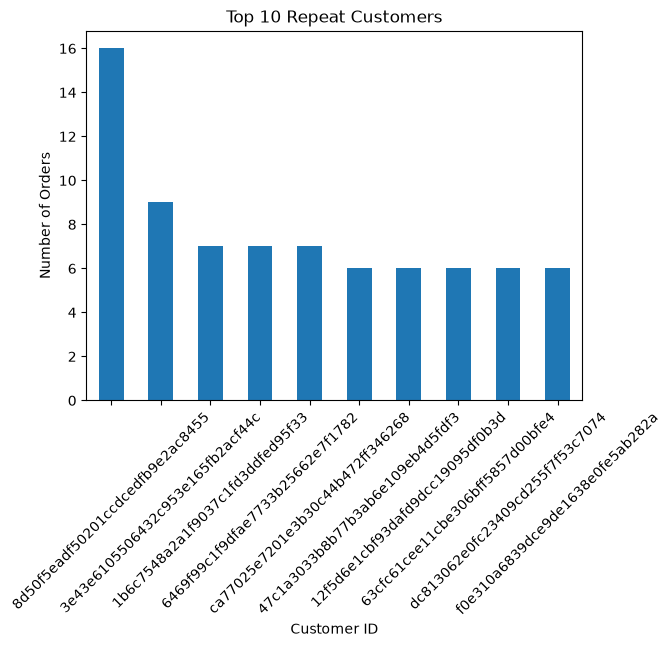

In [48]:
purchase_frequency.plot(kind="bar")

plt.title("Top 10 Repeat Customers")
plt.xlabel("Customer ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.show()

# 💡 Business Insights

### 1. Monthly Revenue Trend
- Revenue remained relatively stable during the first eight months of the year.
- Sales reached their highest level in **May**, indicating a seasonal increase in customer purchases.
- Revenue declined noticeably during **September and October**, followed by a partial recovery in **November**.
- The business may benefit from promotional campaigns during lower-performing months to stabilize revenue.

---

### 2. Product Category Performance
- Revenue is concentrated among a small number of product categories.
- Categories such as **cama_mesa_banho** and **beleza_saude** generated the highest revenue.
- Several lower-ranked categories contributed significantly less revenue, suggesting opportunities for portfolio optimization.
- High-performing categories should be prioritized for inventory planning and marketing campaigns.

---

### 3. Customer State Analysis
- **São Paulo (SP)** generated the highest revenue by a considerable margin.
- Rio de Janeiro (RJ) and Minas Gerais (MG) are the next strongest revenue contributors.
- Revenue is heavily concentrated in a few states, while many states contribute comparatively smaller amounts.
- Expanding marketing efforts in underperforming regions could help increase geographical revenue distribution.

---

### 4. Payment Method Analysis
- **Credit Card** is the dominant payment method, accounting for approximately **74%** of all transactions.
- **Boleto** is the second most frequently used payment method.
- Voucher and debit card payments represent only a small share of total transactions.
- Optimizing the checkout experience for credit card users could improve customer satisfaction and conversion rates.

---

### 5. Seller Performance
- A relatively small number of sellers generate a large proportion of total revenue.
- The highest-performing seller significantly outperforms the remaining sellers.
- Revenue concentration suggests that supporting mid-performing sellers could improve overall marketplace performance.
- Monitoring seller performance can help identify best practices and improve operational efficiency.

---

### 6. Customer Revenue Analysis
- Customer spending is unevenly distributed across the customer base.
- The highest-value customer generated substantially more revenue than other customers.
- A small group of customers contributes a significant share of overall revenue.
- Implementing loyalty programs and personalized marketing strategies may improve customer retention and increase lifetime value.

---

### 7. Repeat Customer Analysis
- Most customers placed a relatively small number of orders.
- Only a few customers made frequent repeat purchases.
- Encouraging repeat purchases through targeted promotions, rewards, and personalized recommendations could improve long-term revenue.
- Increasing customer retention may be more cost-effective than acquiring new customers.

# ⭐ Interview Story (STAR Format)

### Situation

An e-commerce company wanted to better understand customer purchasing behavior, revenue trends, seller performance, and payment preferences to support data-driven business decisions and improve customer retention.

### Task

Analyze multiple relational datasets to identify customer behavior patterns, product and seller performance, revenue trends, and purchasing insights using SQL and Python.

### Action

- Imported and cleaned six relational datasets.
- Merged multiple tables into a unified analytical dataset using Python.
- Performed business-oriented SQL analysis to answer 60 business questions.
- Conducted exploratory data analysis (EDA) using Pandas and Matplotlib.
- Built business visualizations to analyze revenue trends, customer behavior, payment methods, product performance, and seller performance.
- Generated actionable business insights to support strategic decision-making.

### Result

The analysis identified high-performing products, top revenue-generating regions, preferred payment methods, top customers, and leading sellers. The project provides a complete customer analytics workflow that enables businesses to better understand customer purchasing behavior, optimize marketing strategies, improve seller performance, and support data-driven decision-making.

# 📌 Conclusion

This project demonstrates an end-to-end customer analytics workflow using Python to transform raw e-commerce data into meaningful business insights.

The analysis included data loading, data exploration, data quality assessment, data cleaning, merging multiple relational datasets, feature engineering, exploratory data analysis (EDA), and customer analytics.

Key findings highlighted customer purchasing behavior, revenue trends, product performance, seller performance, payment preferences, and repeat customer patterns. These insights can support business decisions related to customer retention, inventory planning, marketing strategies, and marketplace performance.

This notebook complements the SQL analysis by providing visual storytelling and business-oriented insights, showcasing the complete analytics workflow from raw data to actionable recommendations.

---

# 🚀 Skills Demonstrated

### Python

- Data Loading
- Data Cleaning
- Data Exploration
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insight Generation

### Pandas

- DataFrame Operations
- Merge Multiple Tables
- GroupBy & Aggregation
- Filtering & Sorting
- Handling Missing Values
- Feature Creation

### Matplotlib

- Line Charts
- Bar Charts
- Pie Charts
- Business Visualizations

### Business Analytics

- Customer Analytics
- Revenue Analysis
- Product Performance Analysis
- Seller Performance Analysis
- Payment Method Analysis
- Customer Purchase Behavior

---

# ✅ Project Completed

This notebook successfully demonstrates how Python can be used to analyze a relational e-commerce dataset and generate actionable business insights. Together with the accompanying SQL analysis, the project showcases an end-to-end customer analytics workflow suitable for business decision-making and data-driven reporting.

---
## 📬 Author

**Sameer Sharma**

Aspiring Data Analyst

If you found this project helpful, feel free to ⭐ the repository.